In [11]:
import pygimli as pg 
import matplotlib.pyplot as plt
import numpy as np
from pygimli.physics import ert
import pygimli.meshtools as mt
from scipy.interpolate import griddata
import pandas as pd

16/03/26 - 21:02:00 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 


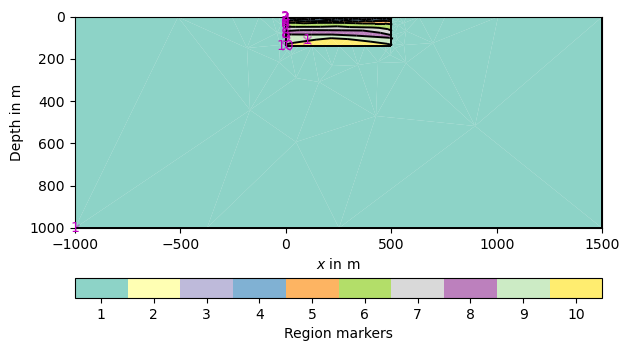

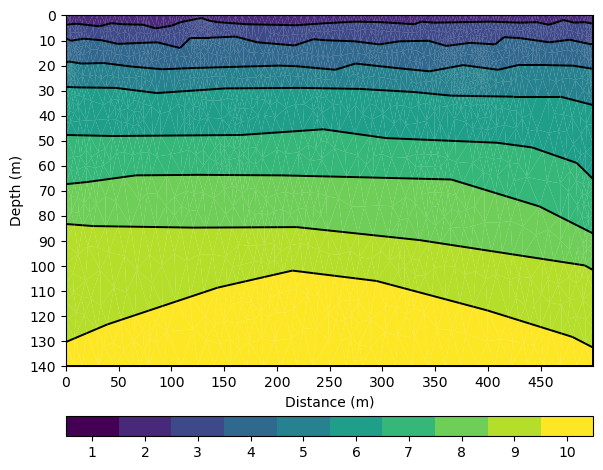

In [12]:
world=mt.createWorld(start=[-1000,0],end=[1500,-1000],worldMarker=1)

poly=mt.createRectangle(start=[0, -140], end=[500, 0], marker=1)

interfaces = []

for i in range(9):

    coords = np.loadtxt(f'shape_{i}.txt')
    line = mt.createPolygon(coords, isClosed=False)
    interfaces.append(line)

geom = mt.mergePLC([world] + interfaces + [poly])

geom.addRegionMarker(pos=[0, -1], marker=2)
geom.addRegionMarker(pos=[0, -6], marker=3)
geom.addRegionMarker(pos=[0, -12], marker=4)
geom.addRegionMarker(pos=[0, -23], marker=5)
geom.addRegionMarker(pos=[0, -40], marker=6)
geom.addRegionMarker(pos=[0, -60], marker=7)
geom.addRegionMarker(pos=[0, -80], marker=8)
geom.addRegionMarker(pos=[0, -100], marker=9)
geom.addRegionMarker(pos=[0, -140], marker=10)


pg.show(geom,showMesh=True,quality=34)

mesh_cut = mt.createMesh(geom, quality=34)

x_min,x_max= 0,500
y_min,y_max= -140,0

ax, cbar = pg.show(mesh_cut, data=mesh_cut.cellMarkers(), 
                   showMesh=False, aspect='auto', 
                   cmap=plt.get_cmap("viridis", 10))
cbar.mappable.set_clim(0.5, 10.5)
cbar.set_ticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

ax.set_xlim(0, 500)
ax.set_ylim(-140, 0)
ax.set_yticks(np.arange(-140, 1, 10)) 
ax.set_xticks(np.arange(0, 500, 50)) 
ax.set_xlabel("Distance (m)")   
ax.set_ylabel("Depth (m)")

plt.draw()

16/03/26 - 21:02:01 - pyGIMLi - INFO - Cache c:\Users\sider\.conda\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 18): C:\Users\sider\AppData\Roaming\pygimli\Cache\17970140561219481632


Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x1926e108590>)

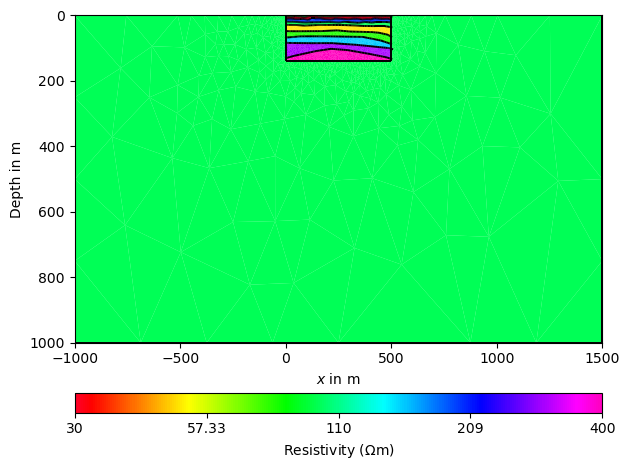

In [13]:
spacing=25
scheme=ert.createData(
    elecs=np.linspace(start=0,stop=500,num=len(np.arange(0,501,spacing)))
    , schemeName='dd'
)
print(scheme)
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p-[0,0.1]) # create 2  nodes for FTDT
mesh_fwr=mt.createMesh(geom,quality=34)
rhomap=[[1,100],
        [2,100],
        [3,30],
        [4,200],
        [5,100],
        [6,50],
        [7,80],
        [8,150],
        [9,300],
        [10,400]
        ] # resistivity για κάθε marker
pg.show(mesh_fwr,data=rhomap,label=pg.unit('res'), cMap='gist_rainbow',logScale=True,aspect='auto')

16/03/26 - 21:02:02 - pyGIMLi - INFO - Data error estimate (min:max)  0.01000646453191016 : 0.01477671087397909


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100
Value for marker 6: 60 Ohm.m, data saved to timelapse_0.dat
Log0.txt created with details of Step 0
Done Step 0


16/03/26 - 21:02:03 - pyGIMLi - INFO - Data error estimate (min:max)  0.010006464776187888 : 0.014831885951130209


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100
Value for marker 6: 57 Ohm.m, data saved to timelapse_1.dat
Log1.txt created with details of Step 1
Done Step 1


16/03/26 - 21:02:04 - pyGIMLi - INFO - Data error estimate (min:max)  0.010006464886587687 : 0.014871259216716599


...

16/03/26 - 21:02:09 - pyGIMLi - INFO - Data error estimate (min:max)  0.010006414159357331 : 0.018404632948980038


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100
Value for marker 6: 10 Ohm.m, data saved to timelapse_8.dat
Log8.txt created with details of Step 8
Done Step 8


16/03/26 - 21:02:10 - pyGIMLi - INFO - Data error estimate (min:max)  0.01000638204193834 : 0.02295302445376775


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100
Value for marker 6: 5 Ohm.m, data saved to timelapse_9.dat
Log9.txt created with details of Step 9
Done Step 9


(<Axes: xlabel='a', ylabel='m'>,
 <matplotlib.colorbar.Colorbar at 0x192ab94ae90>)

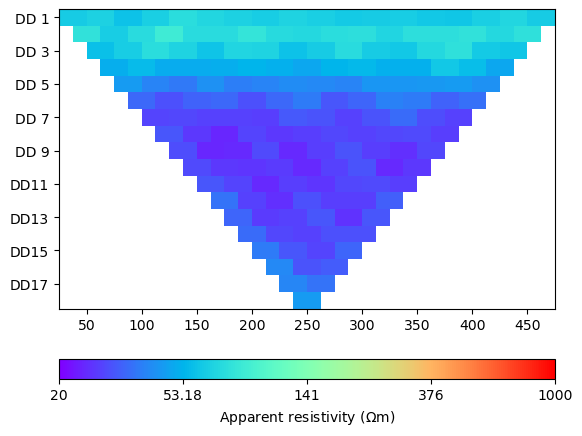

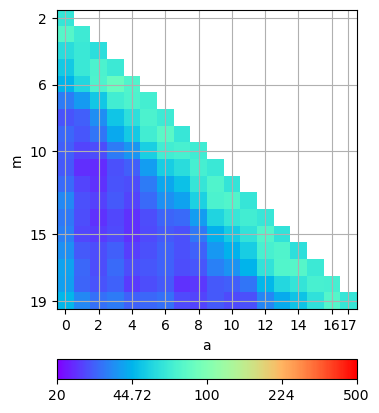

In [14]:
#timelapse, changing marker6 (layer 6), assume it changes due to pollution
new_vals=[60,57,55,53,50,40,30,20,10,5]
for i, rho_val in enumerate(new_vals):
    rhomap[5][1]=rho_val
    data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=1, noiseAbs=1e-6, seed=1337)
    data.remove(data['rhoa']<0)

    filename=f'timelapse_{i}.dat'
    print(f'Value for marker 6: {new_vals[i]} Ohm.m, data saved to {filename}')
    with open(f'log{i}.txt', 'w') as f:
        print(f"Step {i} | Marker6: {rho_val} ", file=f)
        print(f"Norm Err: {np.linalg.norm(data['err'])}", file=f)
        print(f"Min/Max Rhoa: {min(data['rhoa'])} / {max(data['rhoa'])}", file=f)
        print(f"Data: {data}", file=f)
    print(f'Log{i}.txt created with details of Step {i}')
    data.save(filename)
    print(f'Done Step {i}')

    np.save(f'res_all_t_{i}.npy', np.column_stack([data['rhoa']])) #Resistivity changes, keep inside the loop


np.save(f'abmn_timelapse.npy', np.column_stack([data['a'], data['b'], data['m'], data['n']])) #Geometry doesn't change.

ert.show(data,cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')   #pseudosection for last step (confirmation)
pg.viewer.mpl.showDataContainerAsMatrix(data,'a','m', 'rhoa',cMap='rainbow',cMin=20,cMax=500,logScale=True,title='DD')


In [15]:
# Function to handle NaN values and get the NaN mask

def fill_nan(image):
    
    nan_mask = np.isnan(image)
    mean_value = np.nanmean(image)
    image[nan_mask] = mean_value

    return image, nan_mask


# Function to reconstruct the image using significant indices and their values

def reconstruct_compressed_image(image_shape, significant_indices, pixel_values):

    # Create an empty image with the given shape
    compressed_image = np.full(image_shape, np.nan)

    # Assign the provided pixel values to the significant indices
    compressed_image[significant_indices] = pixel_values

    # Interpolate to fill in the missing values
    x, y = np.meshgrid(np.arange(image_shape[1]), np.arange(image_shape[0]))
    mask = ~np.isnan(compressed_image)
    interpolated_image = griddata(
        (x[mask], y[mask]),  # Points with known values
        compressed_image[mask],  # Known values
        (x, y),  # Points to interpolate
        method='linear'  # Interpolation 
        )
    return interpolated_image


# Function to perform SVD and reconstruct image using significant pixels

def compress_and_reconstruct(image, num_singular_values,method='DD'):

    # Handle NaN values and get the NaN mask
    image, nan_mask = fill_nan(image)

    # Perform SVD
    U, S, Vt = np.linalg.svd(image, full_matrices=False)

    # Keep only the top 'num_singular_values' singular values
    U_reduced = U[:, :num_singular_values]
    S_reduced = np.diag(S[:num_singular_values])
    Vt_reduced = Vt[:num_singular_values, :]

    # Reconstruct the image using significant pixels
    compressed_image = np.dot(U_reduced, np.dot(S_reduced, Vt_reduced))

    # Identify significant pixel indices based on contributions
    contributions = np.abs(U_reduced) @ np.abs(Vt_reduced)

    rows,cols = np.arange(image.shape[0]),np.arange(image.shape[1])
 
    z=rows/np.max(rows)
    if method == 'SLM':
        z_factor = 0.6
    elif method == 'DD':
        # 0.4 for SLM, 0.2 for DD
        z_factor = 0.5
    else:
        print('error, choose method')

    depth_weight=1+z_factor*z   
    depth_weight=depth_weight[:,None] #2D IMPORTANT!!! 1D->WEIGHTING MORE TO DISTANT PIXELS  
    contributions*=depth_weight

    contributions[nan_mask] = -np.inf
    rows_0=np.where(~nan_mask[:,0])[0] #only non-nans for the fist column to force the linear interp   

    if len(rows_0)>0:
        r_min=rows_0[0]
        r_max=rows_0[-1]
        r_med=rows_0[len(rows_0)//2]
        contributions[r_min,0]=np.inf 
        contributions[r_max,0]=np.inf
        contributions[r_med,0]=np.inf   #force to include them

    flat_indices = np.argsort(contributions.flatten())[::-1][:num_singular_values]

    #flat_indices=np.r_[0,image.shape[0]*image.shape[1]-1,flat_indices]
    #Convert flat indices to 2D indices

    significant_indices = np.unravel_index(flat_indices, image.shape)

    #Restore NaN values in the original positions
    compressed_image[nan_mask] = np.nan
 
    return compressed_image, significant_indices,nan_mask


#Function to plot ERT measurements as a checkerboard heatmap

def plot_ert_checkerboard(data,plot=0):

    """
    Plots ERT measurements as a checkerboard heatmap.
    Parameters:
    data (pd.DataFrame): A DataFrame containing columns 'A', 'B', 'M', 'N', and 'Res'.
    """

    #Extract unique electrode positions
    electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
    electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}

    #Create a grid
    grid_size = len(electrode_map)
    heatmap = np.full((grid_size, grid_size), np.nan)

    #Map values to the grid
    for _, row in data.iterrows():
        x = electrode_map[row['A']]
        y = electrode_map[row['M']]
        heatmap[y, x] = row['Res']


    if plot==1:

        #Plot the checkerboard heatmap
        plt.imshow(np.log10(heatmap), cmap='gist_rainbow', interpolation='nearest')
        plt.colorbar(label='ERT Measurement Value')
        plt.xticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()), rotation=90)
        plt.yticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()))
        plt.xlabel('Electrode A')
        plt.ylabel('Electrode N')
        plt.title('ERT Checkerboard Heatmap')

        
    return heatmap


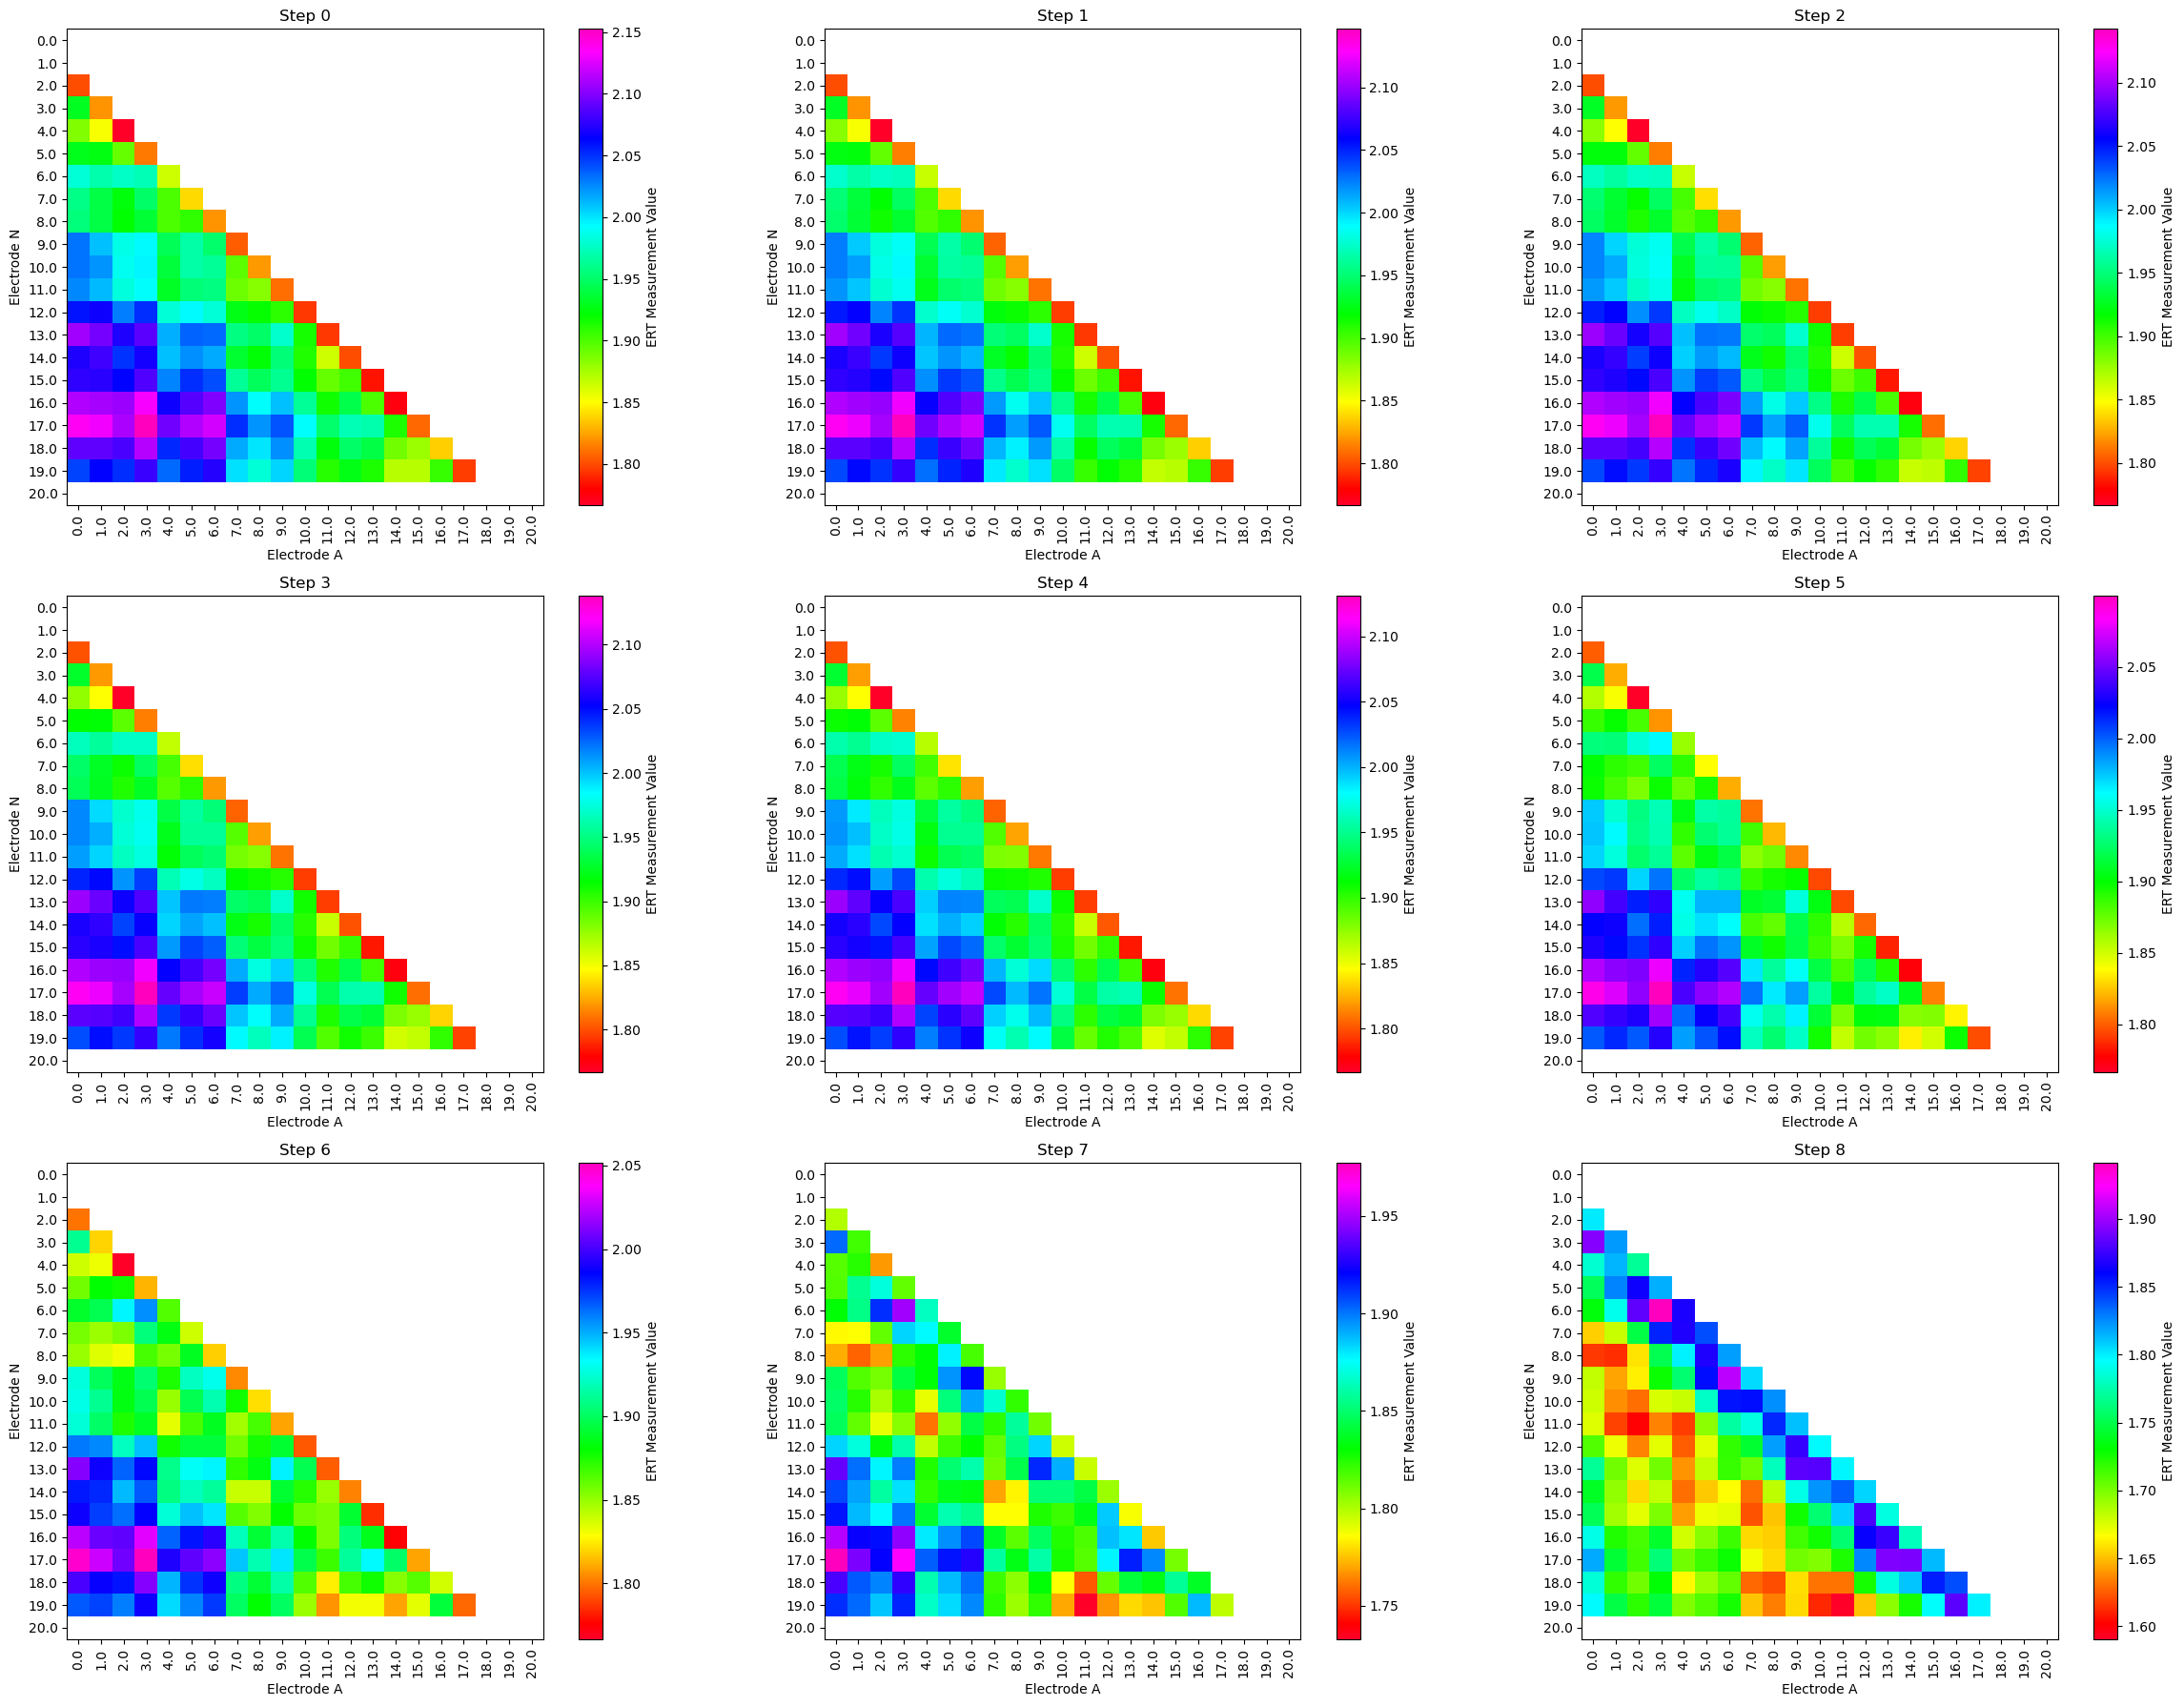

In [16]:
abmn=np.load('abmn_timelapse.npy')
num_singular_values = 30
all_images = []
all_significant_indices = [] #lists to save all steps
all_reconstructed_images = []

plt.figure(figsize=(24, 18))
for i in range(9):
    res_all=np.load(f'res_all_t_{i}.npy')
    data_all=np.column_stack([abmn,res_all[:,0]])
    data=pd.DataFrame(data_all,columns=['A','B','M','N','Res'])

    image=plot_ert_checkerboard(data,plot=0) #keep the numpy array only, no plot
    #svd
    compressed_image, significant_indices, nan_mask = compress_and_reconstruct(image, num_singular_values)
    image[nan_mask] = np.nan 
    all_images.append(image)

    #reconstruction
    pixel_values = compressed_image[significant_indices]
    real_values = image[significant_indices]
    reconstructed_compressed_image = reconstruct_compressed_image(image.shape, significant_indices, real_values)
    predicted_values = reconstructed_compressed_image[significant_indices]
    
    #save to lists
    all_significant_indices.append(significant_indices)
    all_reconstructed_images.append(reconstructed_compressed_image)

    plt.subplot(3, 3, i+1)
    plot_ert_checkerboard(data,plot=1)      
    plt.title(f"Step {i}") 
plt.tight_layout()
plt.show()

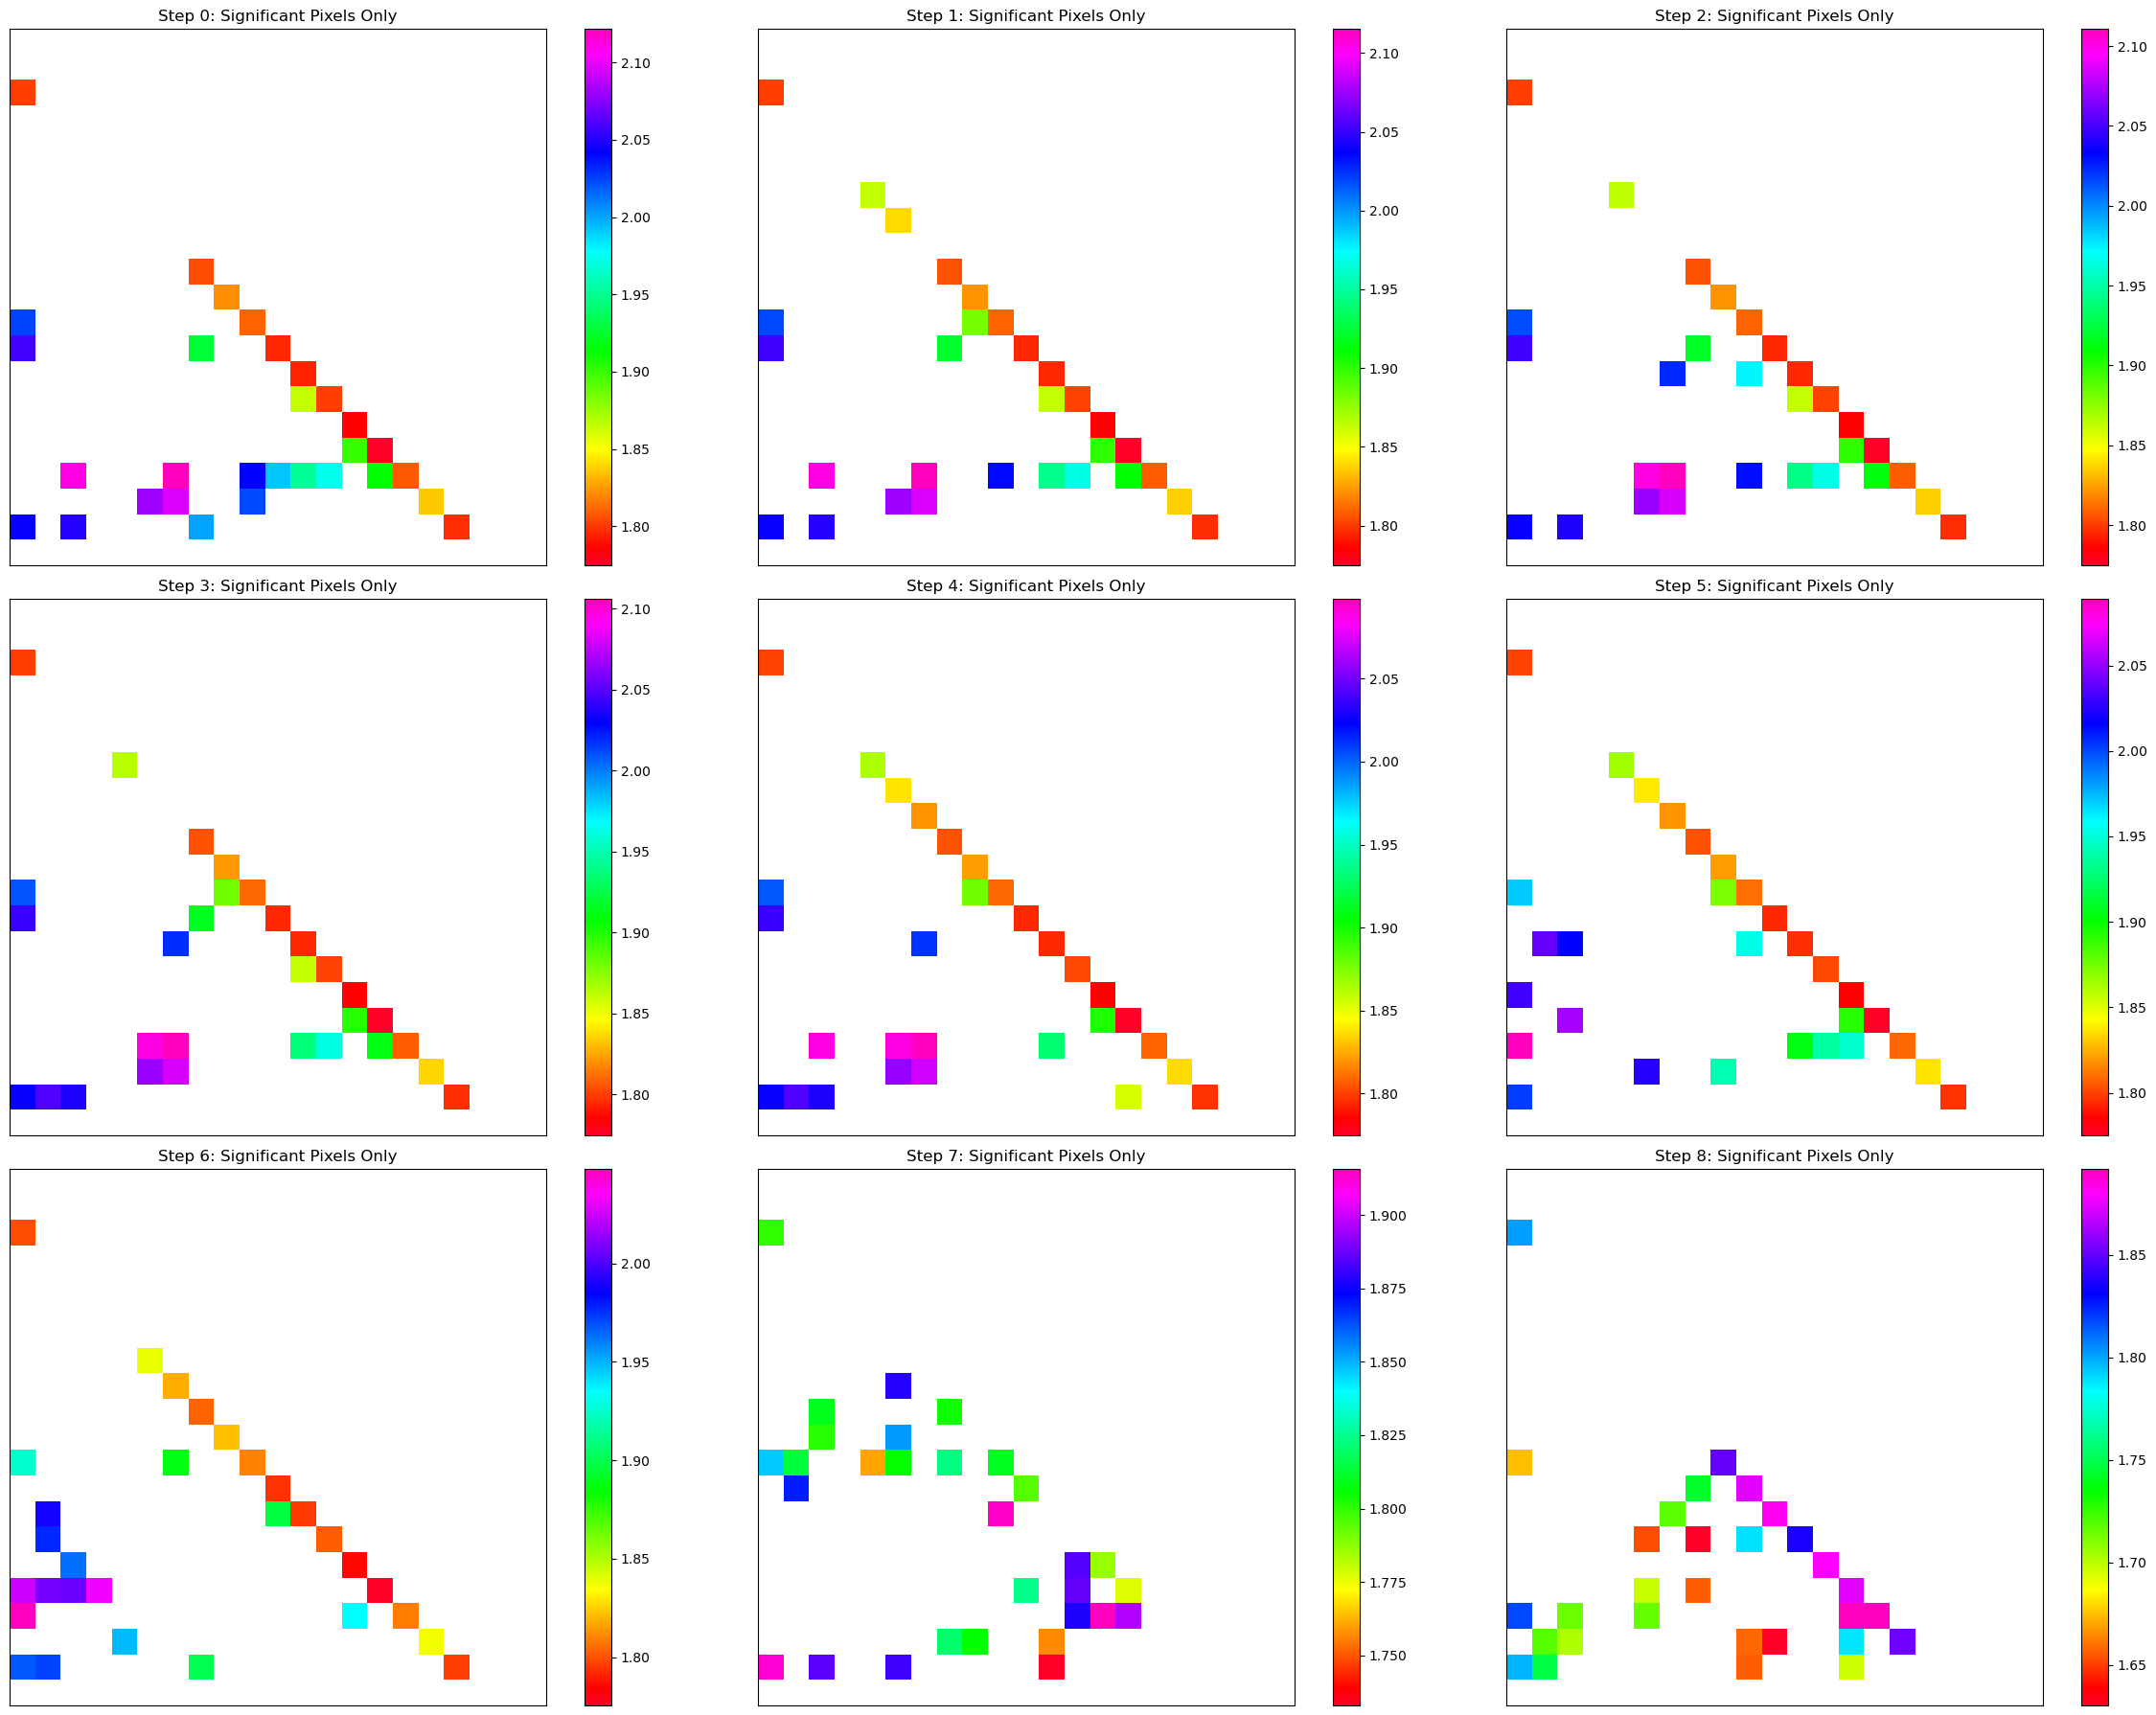

In [17]:
plt.figure(figsize=(24, 18))

for i in range(9):
    ax = plt.subplot(3, 3, i+1)
    
    image = all_images[i].copy()
    significant_indices = all_significant_indices[i]
    reconstructed_compressed_image = all_reconstructed_images[i].copy()
    predicted_values = reconstructed_compressed_image[significant_indices]

    del1 = np.asarray(significant_indices)
    to_plot_image = np.copy(image)
    to_plot_image[:] = np.nan
    to_plot_image[del1[0,:].T, del1[1,:].T] = predicted_values
  

    im = ax.imshow(np.log10(to_plot_image), cmap='gist_rainbow', interpolation='auto')
    plt.colorbar(im, ax=ax)
    
    ax.set_title(f"Step {i}: Significant Pixels Only")
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

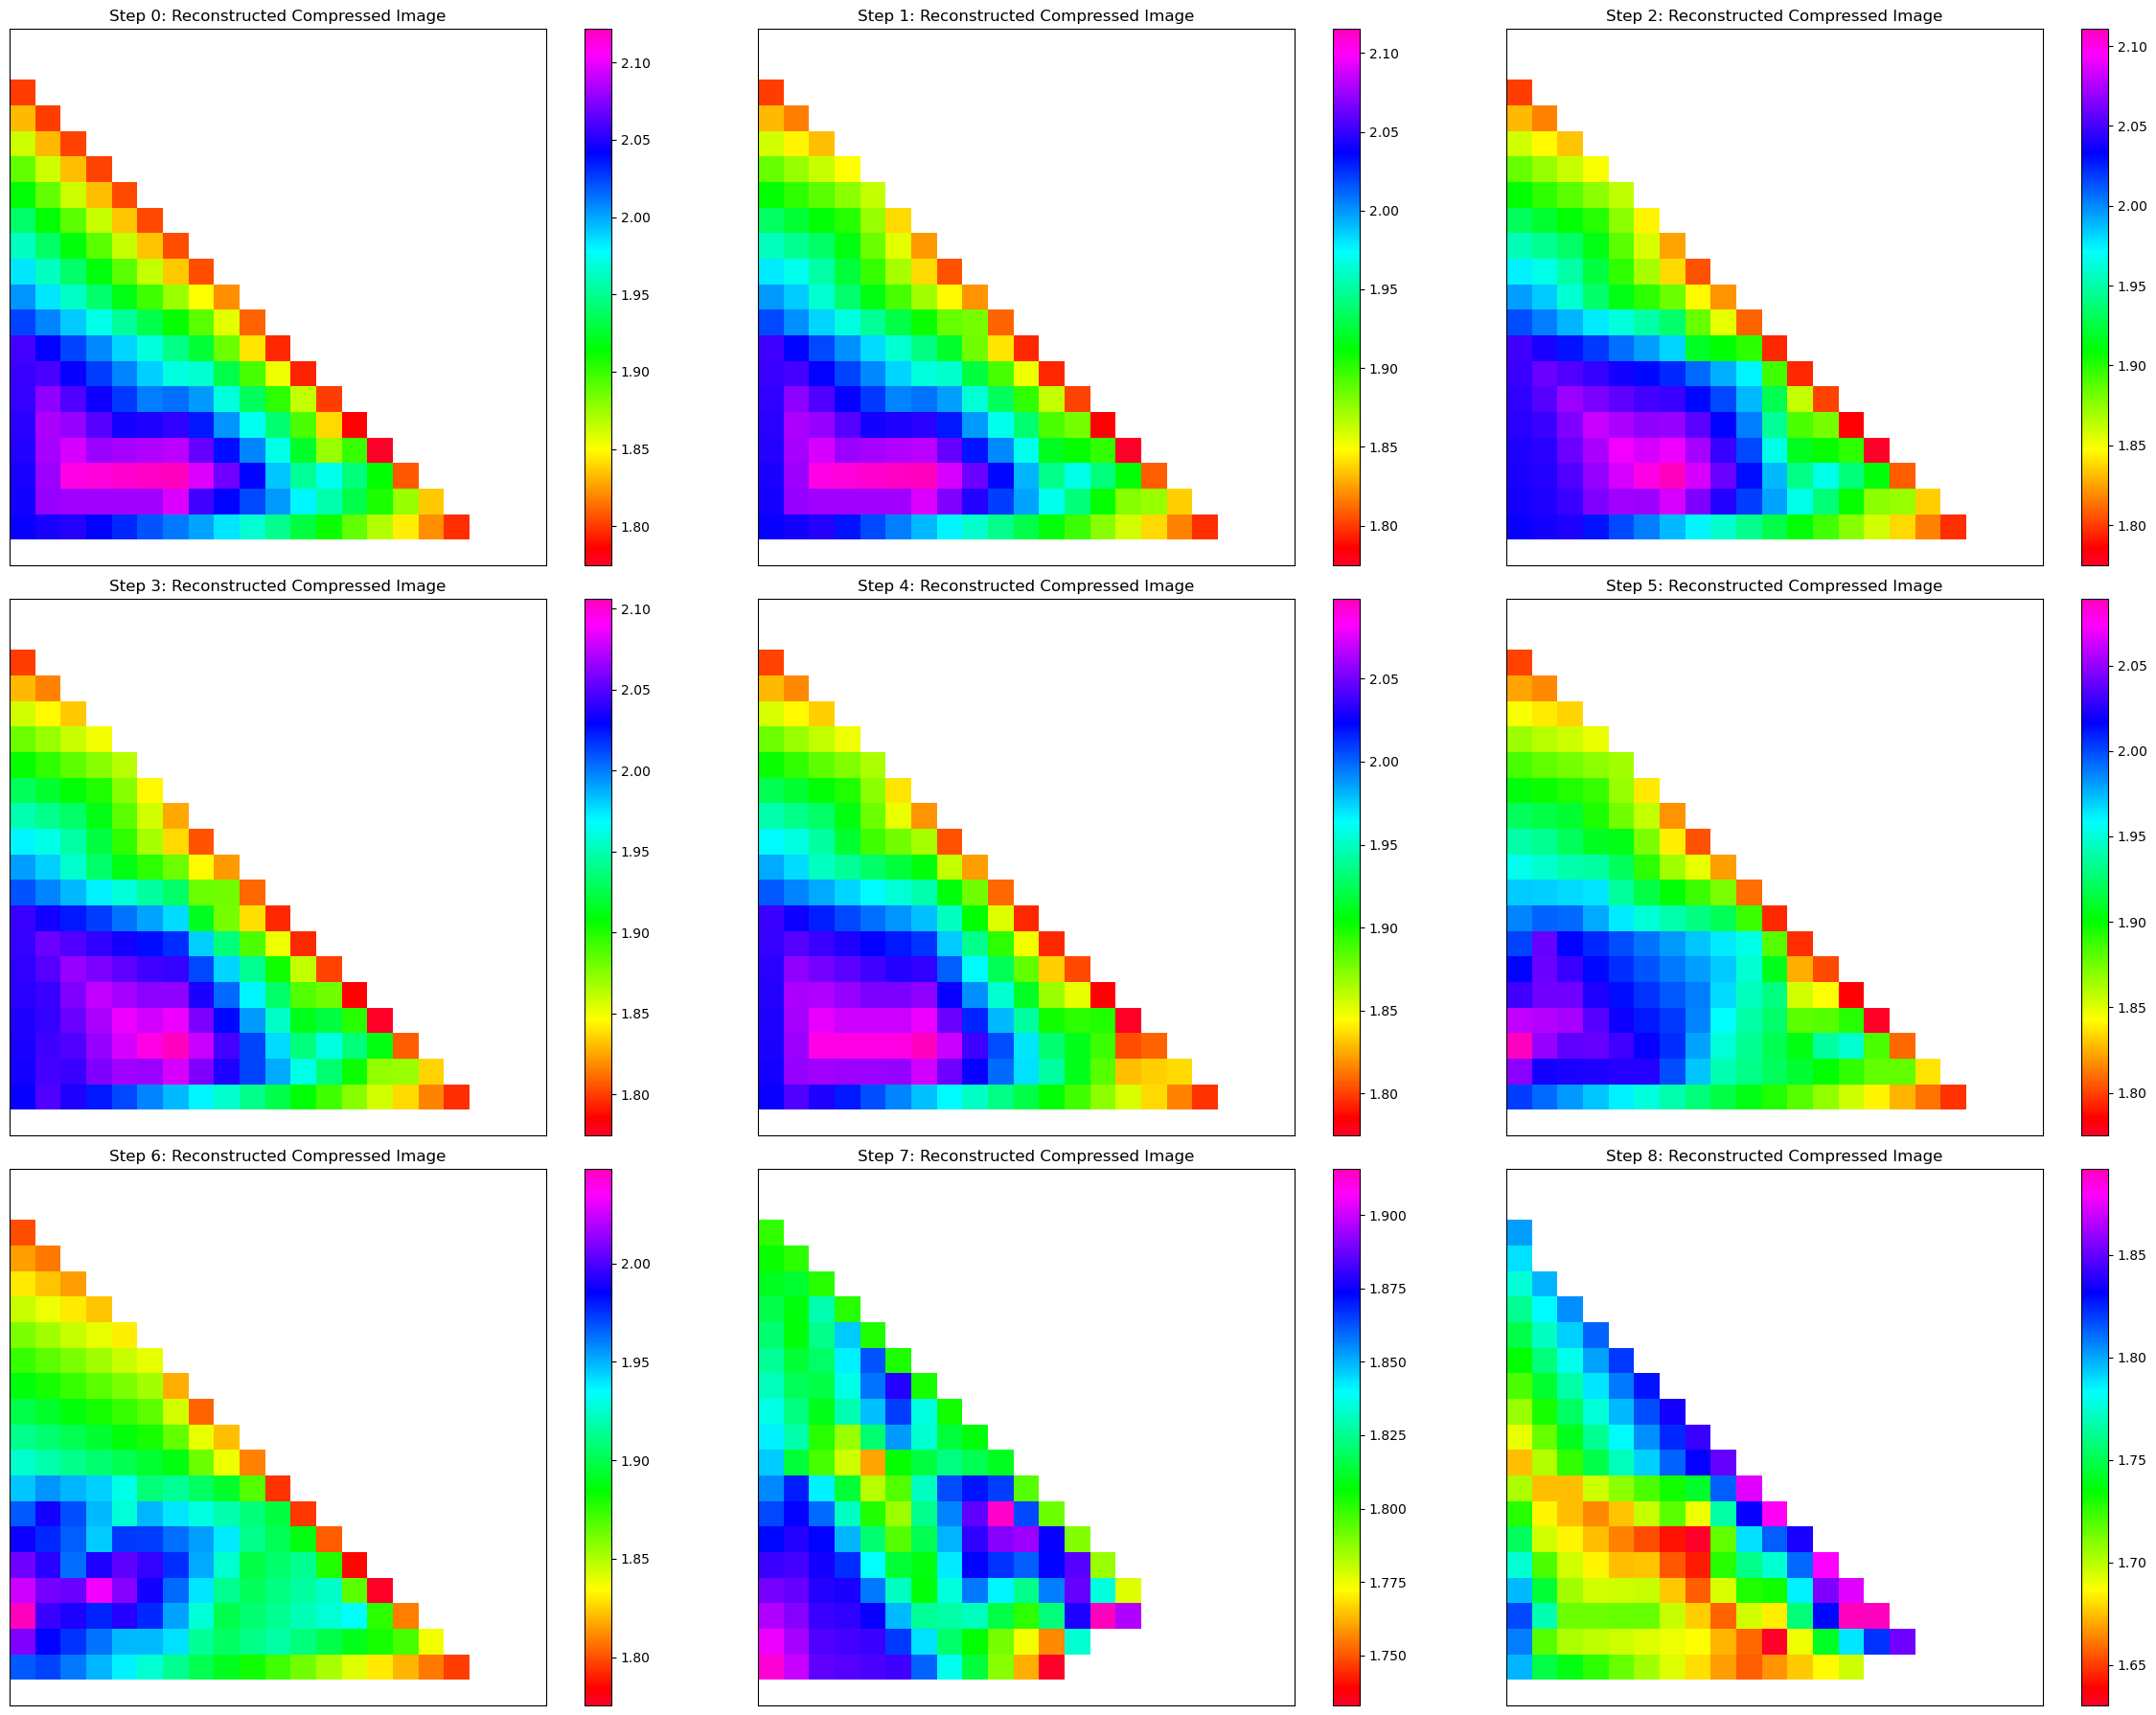

In [18]:
plt.figure(figsize=(24, 18))
for i in range(9):
    ax = plt.subplot(3, 3, i+1)

    reconstructed_compressed_image = all_reconstructed_images[i].copy()
    
    image = all_images[i]
    nan_mask = np.isnan(image)
    
    ax.set_title(f"Step {i}: Reconstructed Compressed Image")
    reconstructed_compressed_image[nan_mask] = np.nan
    im3 = ax.imshow(np.log10(reconstructed_compressed_image), cmap='gist_rainbow')
    plt.colorbar(im3, ax=ax)
    
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

In [19]:
#create for each step the subplot for statistics and export
electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}
for i in range(9):
    image = all_images[i].copy()
    significant_indices = all_significant_indices[i]
    reconstructed_compressed_image = all_reconstructed_images[i].copy()
    nan_mask = np.isnan(all_images[i])
    predicted_values = reconstructed_compressed_image[significant_indices]
    
    fig, ((ax1, ax2, ax5), (ax3, ax4, ax6)) = plt.subplots(2, 3, figsize=(18, 10))
    
    #Original 1
    ax1.set_title("Original Image (with NaNs)")
    im1 = ax1.imshow(image, cmap='gist_rainbow')
    plt.colorbar(im1, ax=ax1)

    #Scatter 2
    ax2.scatter(image.ravel(), reconstructed_compressed_image.ravel(), alpha=0.5)
    lims = [np.nanmin([image, reconstructed_compressed_image]), 
            np.nanmax([image, reconstructed_compressed_image])]
    ax2.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
    ax2.set_aspect('equal')
    ax2.set_xlim(lims); ax2.set_ylim(lims)

    #Reconstructed Image 3
    ax3.set_title("Reconstructed Compressed Image")
    reconstructed_compressed_image[nan_mask] = np.nan
    im3 = ax3.imshow(reconstructed_compressed_image, cmap='gist_rainbow')
    plt.colorbar(im3, ax=ax3)

    #Ratio 4
    ax4.set_title("Ratio Image (Orig/Recon)")
    im4 = ax4.imshow(image / reconstructed_compressed_image, cmap='bwr', vmin=0.8, vmax=1.2)
    plt.colorbar(im4, ax=ax4)

    #Compressed Image 5
    del1 = np.asarray(significant_indices)
    to_plot_image = np.copy(image)
    to_plot_image[:] = np.nan
    to_plot_image[del1[0,:].T, del1[1,:].T] = predicted_values
    ax5.set_title(f"Compressed Image ({num_singular_values} values)")
    im5 = ax5.imshow(to_plot_image, cmap='gist_rainbow')
    plt.colorbar(im5, ax=ax5)

    #Histogram 6
    ax6.set_title("Histogram")
    ax6.hist((image.ravel() / reconstructed_compressed_image.ravel()), bins=100, range=(0.2, 2))

    #Save fig to png
    plt.tight_layout()
    fig.savefig(f'analysis_step_{i}.png')
    plt.close(fig)


    res_all = np.load(f'res_all_t_{i}.npy')
    data_step = pd.DataFrame(np.column_stack([abmn, res_all[:, 0]]), columns=['A', 'B', 'M', 'N', 'Res'])
    
    new_rhoa = []
    for _, row in data_step.iterrows():
        x = electrode_map[row['A']]
        y = electrode_map[row['M']]
        val = reconstructed_compressed_image[y, x]
        new_rhoa.append(val)
        
    np.save(f'res_t_dd_reconstructed_{i}.npy', np.array(new_rhoa))
    print(f"Step {i}: Plot saved as analysis_step_{i}.png and .npy exported.")

Step 0: Plot saved as analysis_step_0.png and .npy exported.
Step 1: Plot saved as analysis_step_1.png and .npy exported.
Step 2: Plot saved as analysis_step_2.png and .npy exported.
Step 3: Plot saved as analysis_step_3.png and .npy exported.
Step 4: Plot saved as analysis_step_4.png and .npy exported.
Step 5: Plot saved as analysis_step_5.png and .npy exported.
Step 6: Plot saved as analysis_step_6.png and .npy exported.
Step 7: Plot saved as analysis_step_7.png and .npy exported.
Step 8: Plot saved as analysis_step_8.png and .npy exported.


16/03/26 - 21:02:19 - pyGIMLi - INFO - Found 2 regions.
16/03/26 - 21:02:19 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
16/03/26 - 21:02:19 - pyGIMLi - INFO - Found 2 regions.
16/03/26 - 21:02:19 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
16/03/26 - 21:02:19 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/03/26 - 21:02:19 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/03/26 - 21:02:19 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1022 Cells: 1900 Boundaries: 1496
16/03/26 - 21:02:19 - pyGIMLi - INFO - Use median(data values)=93.8867658688081


Processing Step 0


16/03/26 - 21:02:20 - pyGIMLi - INFO - Found 2 regions.
16/03/26 - 21:02:20 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
16/03/26 - 21:02:20 - pyGIMLi - INFO - Found 2 regions.
16/03/26 - 21:02:20 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
16/03/26 - 21:02:20 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/03/26 - 21:02:20 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/03/26 - 21:02:20 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1022 Cells: 1900 Boundaries: 1496
16/03/26 - 21:02:20 - pyGIMLi - INFO - Use median(data values)=91.87130991598858


Step 0 Done. Chi2 Original: 6.70 | Chi2 SVD: 3.77


16/03/26 - 21:02:21 - pyGIMLi - INFO - Found 2 regions.
16/03/26 - 21:02:21 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
16/03/26 - 21:02:21 - pyGIMLi - INFO - Found 2 regions.
16/03/26 - 21:02:21 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
16/03/26 - 21:02:21 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/03/26 - 21:02:21 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/03/26 - 21:02:21 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1022 Cells: 1900 Boundaries: 1496
16/03/26 - 21:02:21 - pyGIMLi - INFO - Use median(data values)=92.9628929272271


...

Step 7 Done. Chi2 Original: 5.16 | Chi2 SVD: 9.79


16/03/26 - 21:02:36 - pyGIMLi - INFO - Found 2 regions.
16/03/26 - 21:02:36 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
16/03/26 - 21:02:36 - pyGIMLi - INFO - Found 2 regions.
16/03/26 - 21:02:36 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
16/03/26 - 21:02:36 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/03/26 - 21:02:36 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/03/26 - 21:02:36 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1022 Cells: 1900 Boundaries: 1496
16/03/26 - 21:02:36 - pyGIMLi - INFO - Use median(data values)=53.1201277650377


Processing Step 8


16/03/26 - 21:02:36 - pyGIMLi - INFO - Found 2 regions.
16/03/26 - 21:02:36 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
16/03/26 - 21:02:36 - pyGIMLi - INFO - Found 2 regions.
16/03/26 - 21:02:36 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
16/03/26 - 21:02:36 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/03/26 - 21:02:36 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/03/26 - 21:02:36 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 1022 Cells: 1900 Boundaries: 1496
16/03/26 - 21:02:36 - pyGIMLi - INFO - Use median(data values)=53.54433793835513


Step 8 Done. Chi2 Original: 4.62 | Chi2 SVD: 5.36

All steps processed successfully.


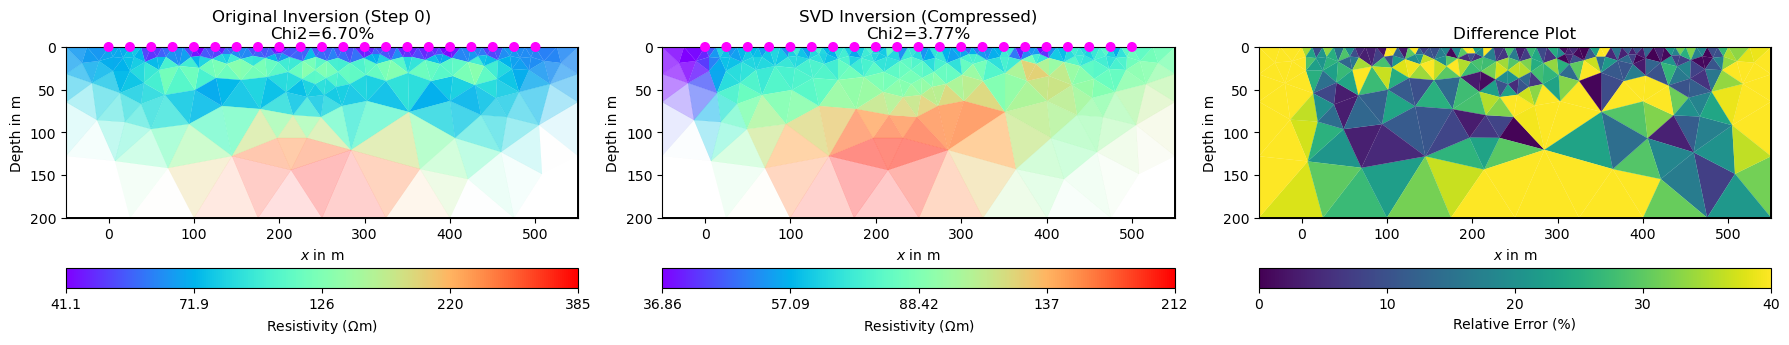

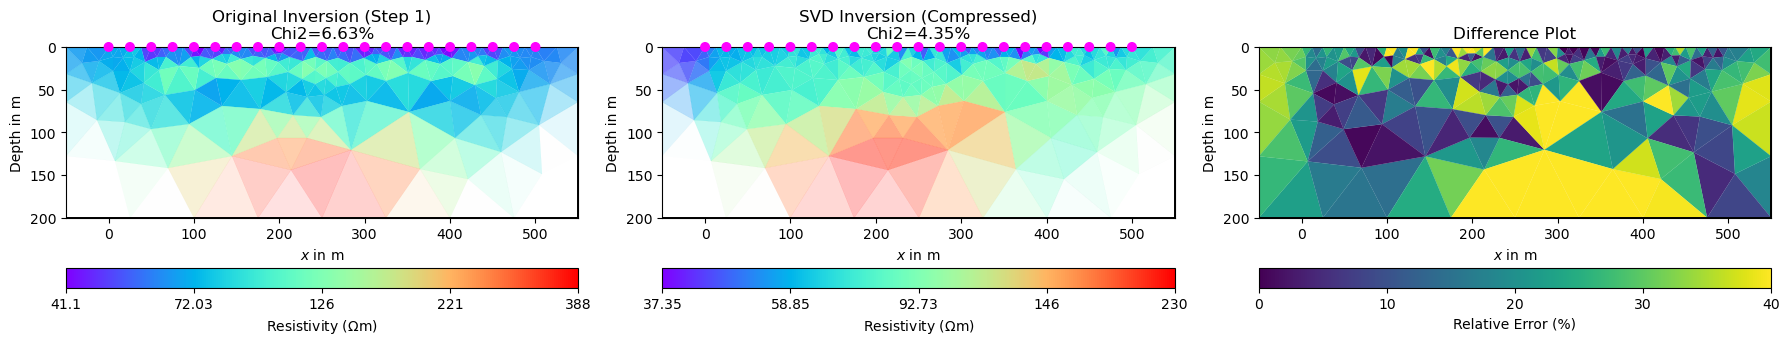

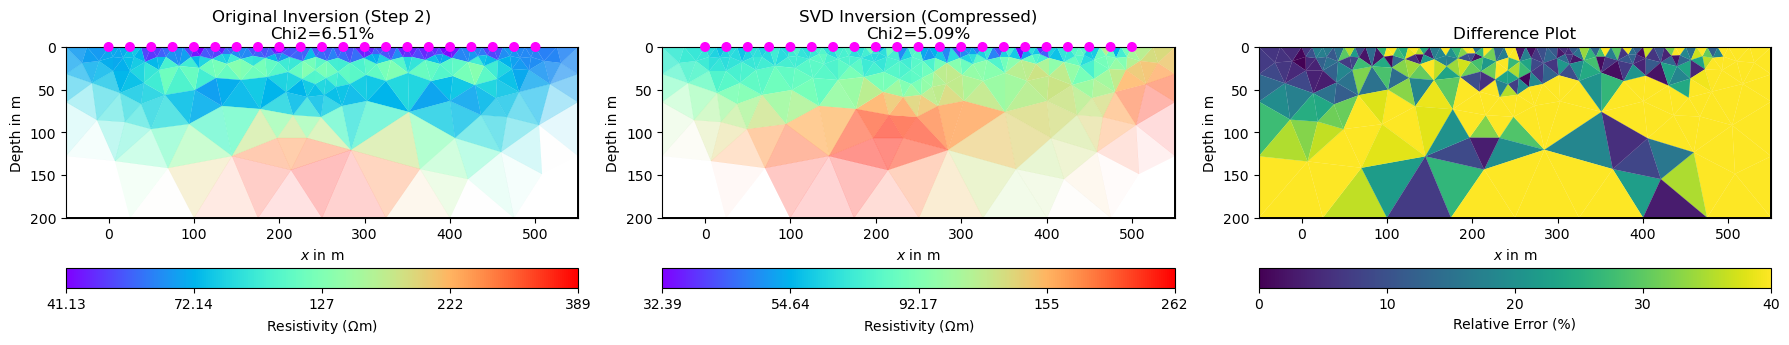

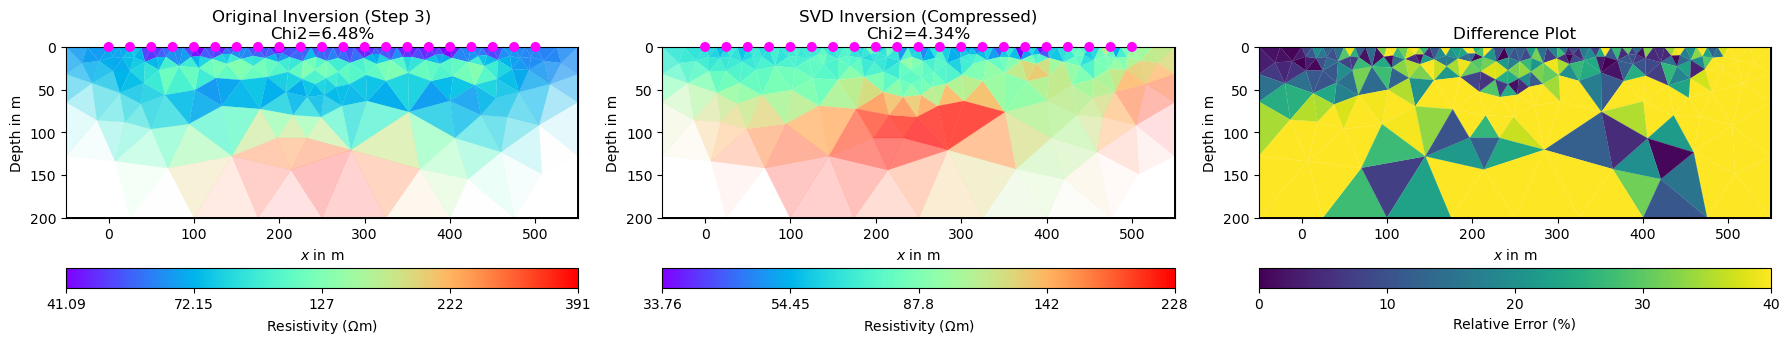

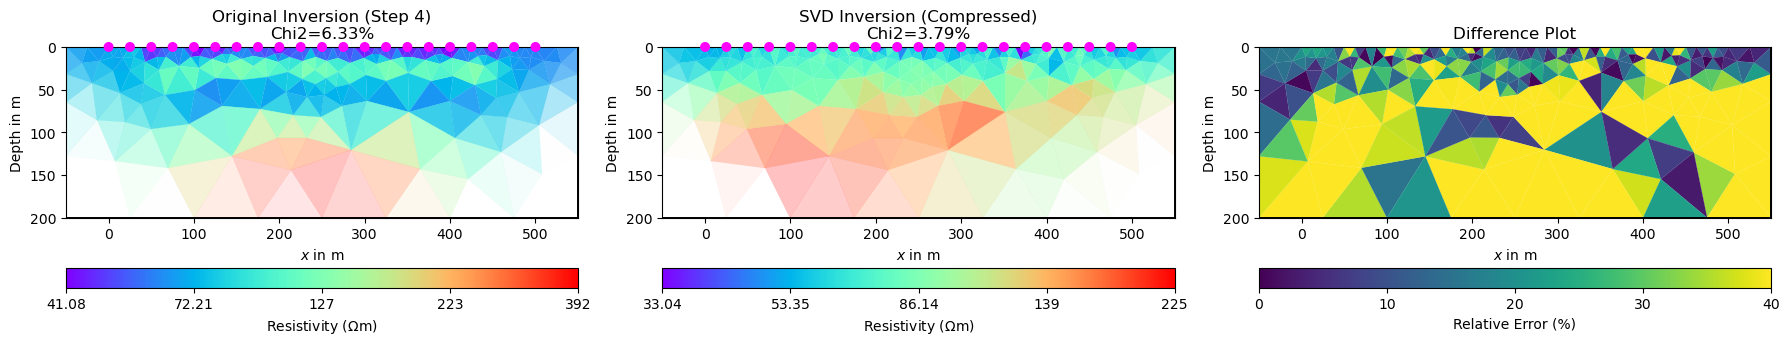

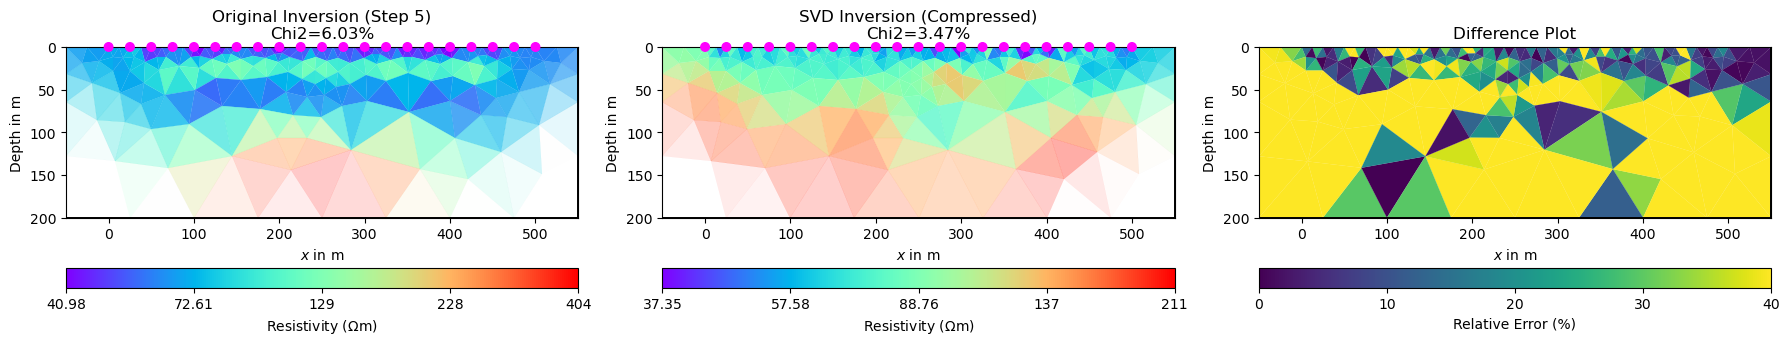

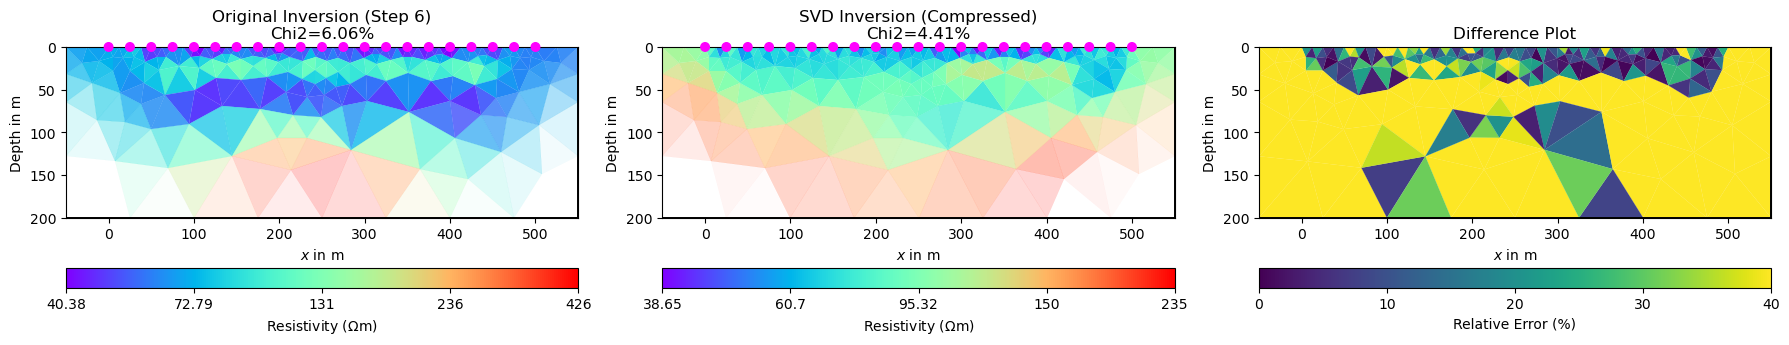

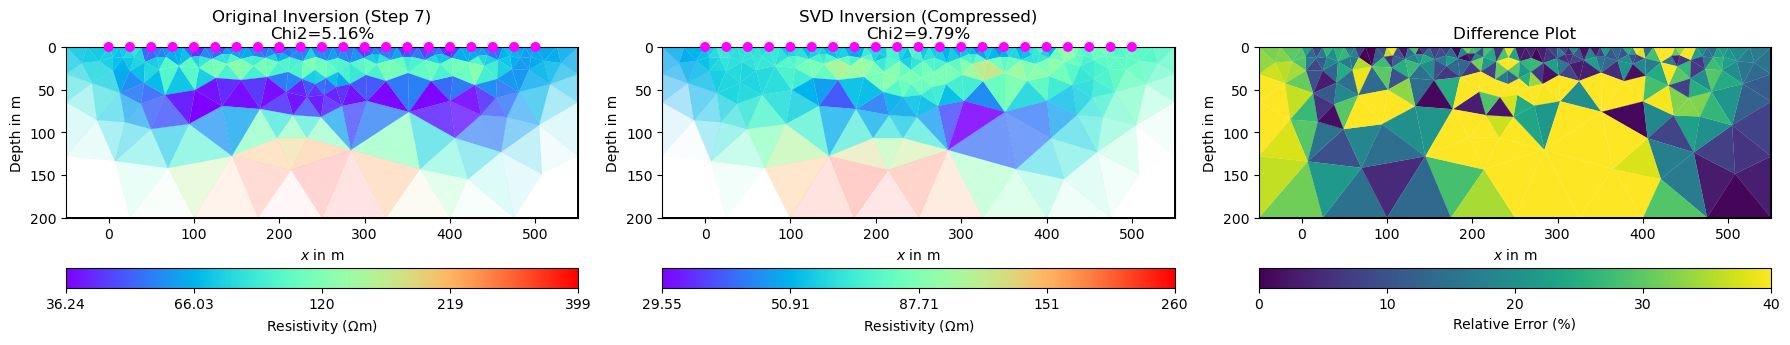

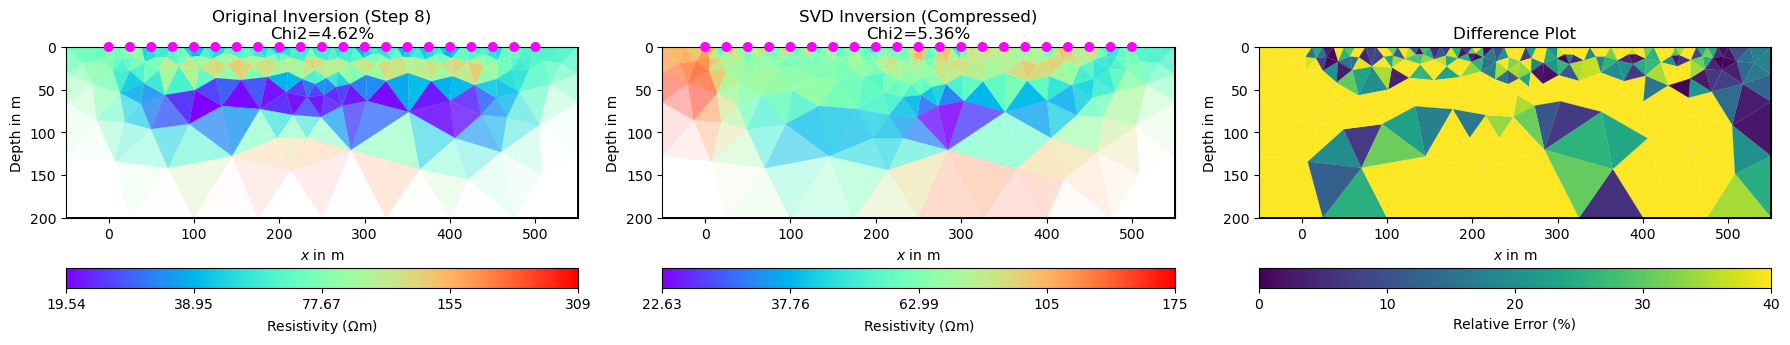

In [20]:
all_mgr1 = []
all_mgr2 = []
all_chi2_1 = []
all_chi2_2 = []

for i in range(9):
    print(f"Processing Step {i}")
    #1.Original Data Inversion
    datafile = f'timelapse_{i}.dat'
    data = pg.load(datafile)
    mgr1 = ert.ERTManager(data)
    inv1 = mgr1.invert(lam=20, verbose=False)
    #Save to lists
    all_mgr1.append(mgr1)
    chi2_1 = mgr1.inv.chi2()
    all_chi2_1.append(chi2_1)


    #SVD-Reconstructed Data Inversion
    data_for_svd = pg.load(datafile) 
    new_rhoa = np.load(f'res_t_dd_reconstructed_{i}.npy')

    if len(data_for_svd['rhoa']) != len(new_rhoa):
        print(f"Original: {len(data_for_svd['rhoa'])}, New: {len(new_rhoa)}")
        # prrrrrrrrrrrrrrrrrrrr 
    else:
        data_for_svd['rhoa'] = new_rhoa
        rhoa_vals = np.array(data_for_svd['rhoa'])
        if np.isnan(rhoa_vals).any() or (rhoa_vals <= 0).any():
            mask = np.isnan(rhoa_vals) | (rhoa_vals <= 0)
            data_for_svd.remove(mask)

    mgr2 = ert.ERTManager(data_for_svd)
    inv2 = mgr2.invert(lam=20, verbose=False)
    #Save to lists
    all_mgr2.append(mgr2)
    chi2_2 = mgr2.inv.chi2()
    all_chi2_2.append(chi2_2)
    
    print(f"Step {i} Done. Chi2 Original: {chi2_1:.2f} | Chi2 SVD: {chi2_2:.2f}")

    #plotting original vs svd vs difference
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    #Original data
    mgr1.showResult(ax=ax1, cMap="rainbow")
    ax1.set_title(f"Original Inversion (Step {i})\nChi2={chi2_1:.2f}%")
    
    #SVD data
    mgr2.showResult(ax=ax2, cMap="rainbow")
    ax2.set_title(f"SVD Inversion (Compressed)\nChi2={chi2_2:.2f}%")

    #Difference Plot
    ax3.set_title("Difference Plot")
    res1 = np.array(inv1)
    res2 = np.array(inv2)
    diff_percent = np.abs((res1 - res2) / res1 * 100)
    
    pd = mgr1.paraDomain
    pg.show(pd, diff_percent, ax=ax3, cMap="viridis", cMin=0, cMax=40, label="Relative Error (%)")

    plt.tight_layout()
    

    fig.savefig(f"comparison_timelapse_{i}.png")
    
    
    
print("\nAll steps processed successfully.")